<a href="https://colab.research.google.com/github/youkjang/gefs_temperature_bias_correction/blob/main/02_quantile_mapping_correction_with_source_files.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GEFS 2-m Temperature Quantile Mapping Bias Correction

## 1. Project overview

- This notebook extends the GEFS 2-m temperature bias-correction workflow from simple mean-bias correction to **quantile mapping**.

- The objective is to test whether a distribution-based correction can improve GEFS ensemble-mean 2-m temperature forecasts when verified against matching GFS analysis fields.


- Quantile mapping adjusts the forecast distribution rather than only removing the mean error.

## 2. Quantile Mapping

- Quantile mapping is a way to correct forecasts by comparing percentiles.
- For temperature hazard, excessive heat depends on the upper tail of the temperature distribution. So, Quantile mapping may improve the forecast RMSE.

#### 2.1 Quantile Mapping Method in this study
1. Find where the raw forecast value sits in the forecast distribution.
2. Find the matching value at the same percentile in the analysis distribution.
3. Use that analysis-side value as the corrected forecast.


## 3. Source-file workflow

The main calculations are imported from the `gefs_bias_correction/` source package in the GitHub repository.

This notebook uses:

| Source file | Purpose |
|---|---|
| `config.py` | Project configuration and domain settings |
| `data_access.py` | GEFS/GFS data access and matching |
| `synthetic.py` | Optional synthetic dataset for debugging |
| `split.py` | Train/test split by initialization date |
| `mean_bias.py` | Mean-bias correction baseline |
| `quantile_mapping.py` | Quantile mapping fit and application |
| `verification.py` | Bias, RMSE, and MAE verification |

For final project results, use `USE_SYNTHETIC = False`. The synthetic option is included only for fast debugging.

## 4. Install and import packages

In [13]:
!pip -q install "eccodes>=2.37.0" cfgrib s3fs "fsspec==2025.3.0"

In [14]:
!pip install git+https://github.com/youkjang/gefs_temperature_bias_correction.git

  Cloning https://github.com/youkjang/gefs_temperature_bias_correction.git to /tmp/pip-req-build-_tggxspo
  Running command git clone --filter=blob:none --quiet https://github.com/youkjang/gefs_temperature_bias_correction.git /tmp/pip-req-build-_tggxspo
  Resolved https://github.com/youkjang/gefs_temperature_bias_correction.git to commit 8c01ed6f145b36f312c7dbb35d5f7156cd3cfa66
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from gefs_bias_correction.config import ProjectConfig, Region
from gefs_bias_correction.synthetic import make_synthetic_t2m_dataset
from gefs_bias_correction.data_access import build_matched_t2m_dataset
from gefs_bias_correction.split import split_train_test_by_init_date
from gefs_bias_correction.mean_bias import (
    compute_mean_bias_by_lead,
    apply_mean_bias_correction,
)
from gefs_bias_correction.quantile_mapping import (
    fit_quantile_mapping_by_lead,
    apply_quantile_mapping_correction,
    make_quantile_mapping_summary_table,
)
from gefs_bias_correction.verification import summarize_by_lead

## 5. User configuration

- 92 GEFS initialization dates from **June 1, 2023 to August 31, 2023**
- five forecast lead times: f024, f048, f072, f096, and f120.



In [16]:
USE_SYNTHETIC = False  # Set True only for quick debugging.
N_QUANTILES = 101
TRAIN_FRACTION = 0.7

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
NETCDF_DIR = OUTPUT_DIR / "netcdf"

for directory in [FIGURE_DIR, TABLE_DIR, NETCDF_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

config = ProjectConfig(
    init_dates=pd.date_range(
        "2023-06-01",
        "2023-08-31",
        freq="D",
    ).strftime("%Y%m%d").tolist(),
    init_hour="00",
    forecast_hours=[24, 48, 72, 96, 120],
    train_fraction=TRAIN_FRACTION,

    region=Region(
        name="CONUS",
        west=-130,
        east=-60,
        south=20,
        north=55,
    ),

    # region = Region(
    # name="Southwest_US",
    # west=-125,
    # east=-100,
    # south=25,
    # north=42,
    # ),

    # region = Region(
    # name="Southern_Plains",
    # west=-107,
    # east=-90,
    # south=25,
    # north=40,
    # ),

    # region = Region(
    # name="Northeast_US",
    # west=-85,
    # east=-66,
    # south=36,
    # north=48,
    # ),

    cache_dir="data/herbie_cache",
    verbose=True,
    skip_missing=True,
)

config

ProjectConfig(init_dates=['20230601', '20230602', '20230603', '20230604', '20230605', '20230606', '20230607', '20230608', '20230609', '20230610', '20230611', '20230612', '20230613', '20230614', '20230615', '20230616', '20230617', '20230618', '20230619', '20230620', '20230621', '20230622', '20230623', '20230624', '20230625', '20230626', '20230627', '20230628', '20230629', '20230630', '20230701', '20230702', '20230703', '20230704', '20230705', '20230706', '20230707', '20230708', '20230709', '20230710', '20230711', '20230712', '20230713', '20230714', '20230715', '20230716', '20230717', '20230718', '20230719', '20230720', '20230721', '20230722', '20230723', '20230724', '20230725', '20230726', '20230727', '20230728', '20230729', '20230730', '20230731', '20230801', '20230802', '20230803', '20230804', '20230805', '20230806', '20230807', '20230808', '20230809', '20230810', '20230811', '20230812', '20230813', '20230814', '20230815', '20230816', '20230817', '20230818', '20230819', '20230820', '2

## 6. Load the matched forecast-analysis dataset

In [17]:
if USE_SYNTHETIC:
    ds = make_synthetic_t2m_dataset(config)
else:
    ds = build_matched_t2m_dataset(config)

ds

Loading init=20230601 00Z, f024, valid=2023-06-02 00Z
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2023-Jun-01 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2023-Jun-02 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ aws


/usr/local/lib/python3.12/dist-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.
Loading init=20230601 00Z, f048, valid=2023-06-03 00Z
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2023-Jun-01 00:00 UTC F48 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2023-Jun-03 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ aws


/usr/local/lib/python3.12/dist-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.
Loading init=20230601 00Z, f072, valid=2023-06-04 00Z
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2023-Jun-01 00:00 UTC F72 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2023-Jun-04 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ aws


...

/usr/local/lib/python3.12/dist-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.
Loading init=20230831 00Z, f120, valid=2023-09-05 00Z
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2023-Aug-31 00:00 UTC F120 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2023-Sep-05 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ aws


/usr/local/lib/python3.12/dist-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.


<xarray.Dataset> Size: 55MB
Dimensions:              (case: 460, latitude: 71, longitude: 141)
Coordinates:
  * case                 (case) int64 4kB 0 1 2 3 4 5 ... 455 456 457 458 459
  * latitude             (latitude) float64 568B 20.0 20.5 21.0 ... 54.5 55.0
  * longitude            (longitude) float64 1kB -130.0 -129.5 ... -60.5 -60.0
    gribfile_projection  object 8B None
    init_date            (case) datetime64[us] 4kB 2023-06-01 ... 2023-08-31
    fhr                  (case) int64 4kB 24 48 72 96 120 24 ... 24 48 72 96 120
    valid_time           (case) datetime64[us] 4kB 2023-06-02 ... 2023-09-05
Data variables:
    forecast_t2m_c       (case, latitude, longitude) float32 18MB 20.65 ... 1...
    analysis_t2m_c       (case, latitude, longitude) float64 37MB 20.61 ... 1...

### Dataset diagnostics

In [18]:
print("USE_SYNTHETIC:", USE_SYNTHETIC)
print("Dataset variables:", list(ds.data_vars))
print("Number of cases:", ds.sizes["case"])
print("Forecast hours:", np.unique(ds["fhr"].values))
print("Init dates:", np.unique(ds["init_date"].values))
print("First valid times:", ds["valid_time"].values[:5])

print("Forecast min/max:",
      float(ds["forecast_t2m_c"].min()),
      float(ds["forecast_t2m_c"].max()))

print("Analysis min/max:",
      float(ds["analysis_t2m_c"].min()),
      float(ds["analysis_t2m_c"].max()))

USE_SYNTHETIC: False
Dataset variables: ['forecast_t2m_c', 'analysis_t2m_c']
Number of cases: 460
Forecast hours: [ 24  48  72  96 120]
Init dates: ['2023-06-01T00:00:00.000000' '2023-06-02T00:00:00.000000'
 '2023-06-03T00:00:00.000000' '2023-06-04T00:00:00.000000'
 '2023-06-05T00:00:00.000000' '2023-06-06T00:00:00.000000'
 '2023-06-07T00:00:00.000000' '2023-06-08T00:00:00.000000'
 '2023-06-09T00:00:00.000000' '2023-06-10T00:00:00.000000'
 '2023-06-11T00:00:00.000000' '2023-06-12T00:00:00.000000'
 '2023-06-13T00:00:00.000000' '2023-06-14T00:00:00.000000'
 '2023-06-15T00:00:00.000000' '2023-06-16T00:00:00.000000'
 '2023-06-17T00:00:00.000000' '2023-06-18T00:00:00.000000'
 '2023-06-19T00:00:00.000000' '2023-06-20T00:00:00.000000'
 '2023-06-21T00:00:00.000000' '2023-06-22T00:00:00.000000'
 '2023-06-23T00:00:00.000000' '2023-06-24T00:00:00.000000'
 '2023-06-25T00:00:00.000000' '2023-06-26T00:00:00.000000'
 '2023-06-27T00:00:00.000000' '2023-06-28T00:00:00.000000'
 '2023-06-29T00:00:00.0000

## 7. Split into training and independent test periods

92 days from 6/1/2023 to 8/31/2023

With a 70/30 train-test split:

- Training dates = 92 × 0.7 = 64 dates
- Testing dates = 92 - 64 = 28 dates

So for each forecast hour:

|fhr | n_case |
|---|---|
| f024 | 28 test cases |
| f048 | 28 test cases |
| f072 | 28 test cases |
| f096 | 28 test cases |
| f120 | 28 test cases |

In [19]:
train_ds, test_ds, train_dates, test_dates = split_train_test_by_init_date(
    ds,
    train_fraction=TRAIN_FRACTION,
)

print("Training dates:", train_dates[0], "to", train_dates[-1])
print("Testing dates:", test_dates[0], "to", test_dates[-1])
print("Training cases:", train_ds.sizes["case"])
print("Testing cases:", test_ds.sizes["case"])

Training dates: 20230601 to 20230803
Testing dates: 20230804 to 20230831
Training cases: 320
Testing cases: 140


The split is based on initialization dates, not random grid points or random cases. This keeps all forecast lead times from the same initialization date together and avoids mixing related forecast cases across the train/test boundary.

## 8. Mean-bias correction baseline

In [20]:
mean_bias_by_lead = compute_mean_bias_by_lead(train_ds)
mean_bias_corrected = apply_mean_bias_correction(test_ds, mean_bias_by_lead)

mean_bias_by_lead

<xarray.DataArray 'mean_bias_c' (fhr: 5, latitude: 71, longitude: 141)> Size: 400kB
array([[[-0.2396307 , -0.2871294 , -0.30463362, ..., -0.17978716,
         -0.20228767, -0.22259855],
        [-0.27712822, -0.25978422, -0.30025578, ..., -0.15041304,
         -0.17338037, -0.19213057],
        [-0.31869555, -0.29572201, -0.30790901, ..., -0.18072224,
         -0.18978453, -0.18759775],
        ...,
        [ 0.84959078,  0.36208963,  0.61880589, ...,  0.58661747,
          0.87865162,  0.41552591],
        [ 0.49458981, -0.76103497,  0.52833986, ...,  0.68489981,
          0.54583788,  0.73490191],
        [ 0.79708862, -1.0069747 , -0.36931658, ...,  0.16068077,
          0.66865158,  0.97505713]],

       [[-0.32079601, -0.35251331, -0.36267042, ..., -0.17891836,
         -0.21298313, -0.23329544],
        [-0.34688854, -0.32110739, -0.35501289, ..., -0.15704346,
         -0.17907763, -0.21095085],
        [-0.36470127, -0.34376097, -0.34485531, ..., -0.19813585,
         -0.21391773, -0.22188616],
...
        [ 0.60509682,  0.16494179,  0.70791101, ...,  0.61040831,
          0.96243858,  0.38509941],
        [ 0.14838266, -0.80302715,  0.59963179, ...,  0.88244247,
          0.75291014,  0.93947315],
        [ 0.79603624, -0.39349604, -0.05755997, ...,  0.5897851 ,
          1.11166334,  1.39978361]],

       [[-0.26209068, -0.29396439, -0.29958916, ..., -0.18208933,
         -0.19865322, -0.231462  ],
        [-0.27865219, -0.26302624, -0.29240274, ..., -0.15162039,
         -0.18224525, -0.20505905],
        [-0.31052685, -0.27974224, -0.28474283, ..., -0.19849539,
         -0.21786976, -0.2153697 ],
        ...,
        [ 0.47103453,  0.1536932 ,  0.8082242 , ...,  0.55916071,
          0.89056683,  0.37087965],
        [ 0.10635042, -0.80083847,  0.73010063, ...,  0.95166016,
          0.79166031,  0.95728683],
        [ 0.76119375, -0.3927145 , -0.0059967 , ...,  0.79634762,
          1.35853767,  1.61962986]]])
Coordinates:
  * fhr                  (fhr) int64 40B 24 48 72 96 120
  * latitude             (latitude) float64 568B 20.0 20.5 21.0 ... 54.5 55.0
  * longitude            (longitude) float64 1kB -130.0 -129.5 ... -60.5 -60.0
    gribfile_projection  object 8B None
Attributes: (12/28)
    GRIB_paramId:                             167
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    GRIB_uvRelativeToGrid:                    0
    ...                                       ...
    GRIB_totalNumber:                         30
    GRIB_units:                               K
    long_name:                                Training mean bias by forecast ...
    units:                                    degC
    standard_name:                            air_temperature
    grid_mapping:                             gribfile_projection

## 9. Fit quantile mapping parameters from the training period

In [21]:
qm_params = fit_quantile_mapping_by_lead(
    train_ds,
    n_quantiles=N_QUANTILES,
)

qm_params

<xarray.Dataset> Size: 9kB
Dimensions:                    (fhr: 5, quantile: 101)
Coordinates:
  * fhr                        (fhr) int64 40B 24 48 72 96 120
  * quantile                   (quantile) float64 808B 0.0 0.01 ... 0.99 1.0
Data variables:
    forecast_quantile_value_c  (fhr, quantile) float64 4kB -0.79 8.45 ... 48.55
    analysis_quantile_value_c  (fhr, quantile) float64 4kB -0.699 7.368 ... 47.9
    n_training_samples         (fhr) int64 40B 640704 640704 ... 640704 640704
Attributes:
    method:       lead-time-dependent pooled quantile mapping
    description:  Quantile mapping parameters estimated by pooling all traini...
    units:        degC

The quantile mapping parameters contain the forecast and analysis quantile values for each forecast hour. In this first version, all grid points and training cases are pooled within each lead time. This provides many samples even when the number of initialization dates is limited.

In [22]:
qm_params.to_netcdf(NETCDF_DIR / "quantile_mapping_parameters.nc")

## 10. Apply quantile mapping to independent test cases

In [23]:
qm_corrected = apply_quantile_mapping_correction(test_ds, qm_params)

qm_corrected

<xarray.DataArray 'qm_corrected_t2m_c' (case: 140, latitude: 71, longitude: 141)> Size: 11MB
array([[[22.4704765 , 22.67835865, 22.86799639, ..., 28.54129672,
         28.54129672, 28.46580054],
        [22.18356506, 22.35565186, 22.4704765 , ..., 28.54129672,
         28.46580054, 28.46580054],
        [21.98819277, 21.98819277, 22.09363242, ..., 28.46580054,
         28.46580054, 28.46580054],
        ...,
        [21.49834682, 20.9193951 , 21.58498506, ..., 12.74549318,
         12.97200847, 12.97200847],
        [21.00557635, 17.58273315, 20.63909746, ..., 12.63223553,
         13.27340807, 13.46157873],
        [22.86799639, 20.07475342, 20.31698608, ..., 12.97200847,
         12.85875082, 13.46157873]],

       [[22.26777752, 22.35028281, 22.43632471, ..., 28.78088379,
         28.78088379, 28.66293335],
        [21.95916748, 22.0722026 , 22.0722026 , ..., 28.89013019,
         28.78088379, 28.66293335],
        [21.71337891, 21.63529683, 21.63529683, ..., 28.78088379,
         28.78088379, 28.78088379],
...
        [11.35506225, 12.04476929, 13.75      , ..., 15.72489929,
         15.36709649, 15.03187766],
        [11.35506225,  8.17394947, 11.35506225, ..., 15.87197876,
         15.87197876, 15.47247424],
        [12.84500434, 10.59536617, 10.83724593, ..., 16.76741028,
         17.09716797, 17.25015669]],

       [[21.98622357, 22.10098267, 21.98622357, ..., 28.44195557,
         28.30413818, 28.30413818],
        [21.64373779, 21.75758362, 21.75758362, ..., 28.44195557,
         28.30413818, 28.30413818],
        [21.42161914, 21.42161914, 21.42161914, ..., 28.30413818,
         28.30413818, 28.18002319],
        ...,
        [ 9.26850325,  7.76924959,  8.44780535, ..., 11.27286577,
         10.87923008, 10.87923008],
        [ 8.09609812,  6.01465175,  7.30751184, ..., 10.11081734,
         10.23889264,  9.85470581],
        [ 8.33055768,  7.12283364,  7.30751184, ..., 10.23889264,
         10.62307947, 10.49504325]]])
Coordinates:
  * case                 (case) int64 1kB 320 321 322 323 ... 456 457 458 459
  * latitude             (latitude) float64 568B 20.0 20.5 21.0 ... 54.5 55.0
  * longitude            (longitude) float64 1kB -130.0 -129.5 ... -60.5 -60.0
    gribfile_projection  object 8B None
    init_date            (case) datetime64[us] 1kB 2023-08-04 ... 2023-08-31
    fhr                  (case) int64 1kB 24 48 72 96 120 24 ... 24 48 72 96 120
    valid_time           (case) datetime64[us] 1kB 2023-08-05 ... 2023-09-05
Attributes:
    long_name:  Quantile-mapped GEFS ensemble-mean 2-m temperature
    units:      degC
    method:     lead-time-dependent pooled quantile mapping

## 11. Verify raw, mean-bias-corrected, and quantile-mapped forecasts

In [24]:
summary_long = make_quantile_mapping_summary_table(
    test_ds=test_ds,
    mean_bias_corrected=mean_bias_corrected,
    quantile_mapped=qm_corrected,
    summarize_func=summarize_by_lead,
)

summary_long

,method,fhr,bias_c,rmse_c,mae_c,n_cases
0,mean_bias,24,-0.046985,1.200638,0.728916,28
1,quantile_mapping,24,-0.042219,1.334100,0.849844,28
2,raw,24,0.375871,1.388045,0.830410,28
3,mean_bias,48,-0.023012,1.405987,0.886416,28
4,quantile_mapping,48,-0.016331,1.540461,1.007699,28
5,raw,48,0.453351,1.608950,0.992252,28
6,mean_bias,72,-0.027029,1.550911,0.999793,28
7,quantile_mapping,72,-0.018976,1.685605,1.120941,28
8,raw,72,0.464549,1.748477,1.099865,28
9,mean_bias,96,0.002664,1.725574,1.125974,28


In [25]:
summary_wide = summary_long.pivot(index="fhr", columns="method", values=["bias_c", "rmse_c", "mae_c", "n_cases"])
summary_wide.columns = [f"{metric}_{method}" for metric, method in summary_wide.columns]
summary_wide = summary_wide.reset_index()

summary_wide["rmse_improvement_mean_bias_c"] = summary_wide["rmse_c_raw"] - summary_wide["rmse_c_mean_bias"]
summary_wide["rmse_improvement_quantile_mapping_c"] = summary_wide["rmse_c_raw"] - summary_wide["rmse_c_quantile_mapping"]
summary_wide["mae_improvement_mean_bias_c"] = summary_wide["mae_c_raw"] - summary_wide["mae_c_mean_bias"]
summary_wide["mae_improvement_quantile_mapping_c"] = summary_wide["mae_c_raw"] - summary_wide["mae_c_quantile_mapping"]
summary_wide["abs_bias_improvement_mean_bias_c"] = np.abs(summary_wide["bias_c_raw"]) - np.abs(summary_wide["bias_c_mean_bias"])
summary_wide["abs_bias_improvement_quantile_mapping_c"] = np.abs(summary_wide["bias_c_raw"]) - np.abs(summary_wide["bias_c_quantile_mapping"])

summary_wide

,fhr,bias_c_mean_bias,bias_c_quantile_mapping,bias_c_raw,rmse_c_mean_bias,rmse_c_quantile_mapping,rmse_c_raw,mae_c_mean_bias,mae_c_quantile_mapping,mae_c_raw,n_cases_mean_bias,n_cases_quantile_mapping,n_cases_raw,rmse_improvement_mean_bias_c,rmse_improvement_quantile_mapping_c,mae_improvement_mean_bias_c,mae_improvement_quantile_mapping_c,abs_bias_improvement_mean_bias_c,abs_bias_improvement_quantile_mapping_c
0,24,-0.046985,-0.042219,0.375871,1.200638,1.334100,1.388045,0.728916,0.849844,0.830410,28.0,28.0,28.0,0.187408,0.053946,0.101494,-0.019434,0.328885,0.333652
1,48,-0.023012,-0.016331,0.453351,1.405987,1.540461,1.608950,0.886416,1.007699,0.992252,28.0,28.0,28.0,0.202963,0.068489,0.105836,-0.015447,0.430339,0.437021
2,72,-0.027029,-0.018976,0.464549,1.550911,1.685605,1.748477,0.999793,1.120941,1.099865,28.0,28.0,28.0,0.197566,0.062872,0.100071,-0.021076,0.437520,0.445573
3,96,0.002664,0.013463,0.506794,1.725574,1.871322,1.932636,1.125974,1.251975,1.232038,28.0,28.0,28.0,0.207061,0.061314,0.106064,-0.019938,0.504129,0.493331
4,120,0.027560,0.040857,0.542408,1.940558,2.096420,2.148674,1.275381,1.402617,1.372155,28.0,28.0,28.0,0.208116,0.052254,0.096774,-0.030462,0.514847,0.501550


In [26]:
summary_long.to_csv(TABLE_DIR / "quantile_mapping_summary_long.csv", index=False)
summary_wide.to_csv(TABLE_DIR / "quantile_mapping_summary_wide.csv", index=False)

## 12. Plot verification results

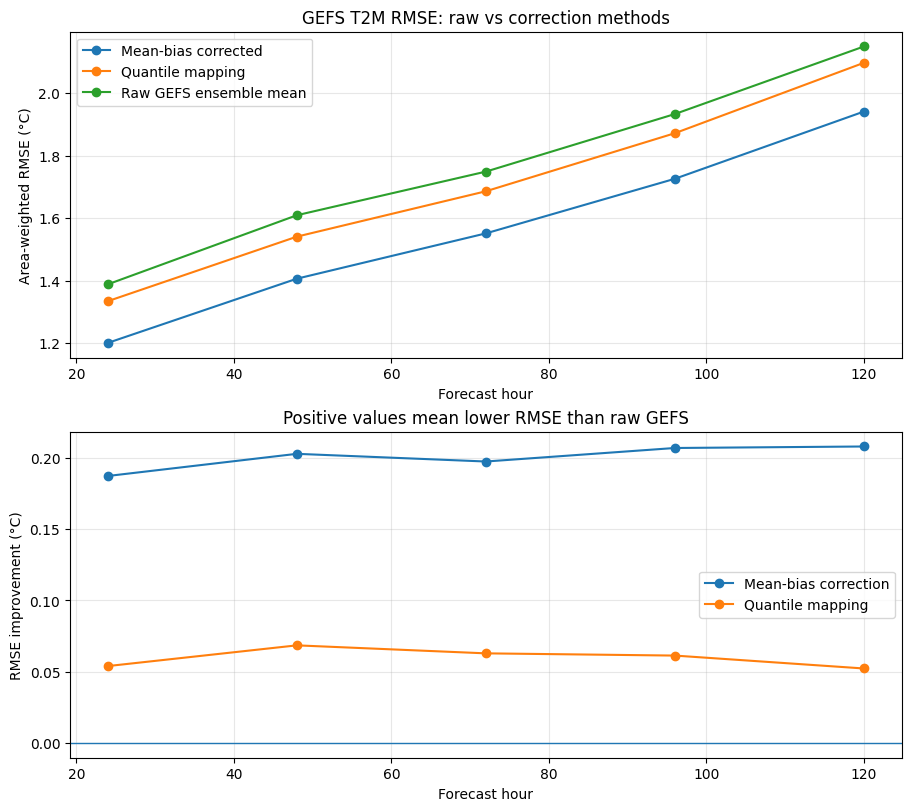

In [27]:
def plot_rmse_method_comparison(summary_long: pd.DataFrame, save_path: Path | None = None):
    label_map = {
        "raw": "Raw GEFS ensemble mean",
        "mean_bias": "Mean-bias corrected",
        "quantile_mapping": "Quantile mapping",
    }

    fig, axes = plt.subplots(2, 1, figsize=(9, 8), constrained_layout=True)

    for method, group in summary_long.groupby("method"):
        group = group.sort_values("fhr")
        axes[0].plot(
            group["fhr"],
            group["rmse_c"],
            marker="o",
            label=label_map.get(method, method),
        )

    axes[0].set_title("GEFS T2M RMSE: raw vs correction methods")
    axes[0].set_xlabel("Forecast hour")
    axes[0].set_ylabel("Area-weighted RMSE (°C)")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].axhline(0.0, linewidth=1)
    axes[1].plot(
        summary_wide["fhr"],
        summary_wide["rmse_improvement_mean_bias_c"],
        marker="o",
        label="Mean-bias correction",
    )
    axes[1].plot(
        summary_wide["fhr"],
        summary_wide["rmse_improvement_quantile_mapping_c"],
        marker="o",
        label="Quantile mapping",
    )
    axes[1].set_title("Positive values mean lower RMSE than raw GEFS")
    axes[1].set_xlabel("Forecast hour")
    axes[1].set_ylabel("RMSE improvement (°C)")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    return fig, axes

fig, axes = plot_rmse_method_comparison(
    summary_long,
    save_path=FIGURE_DIR / "quantile_mapping_rmse_comparison.png",
)
plt.show()

- RMSE increases with forecast lead time for all methods, from f024 to f120.
- Raw GEFS has the highest RMSE at every forecast hour.
- Mean-bias correction performs best, producing the lowest RMSE at all lead times.
- Quantile mapping improves RMSE compared with raw GEFS, but the improvement is smaller than mean-bias correction.
- Mean-bias correction gives about 0.19–0.21°C RMSE improvement, consistently across lead times.
- Quantile mapping gives about 0.05–0.07°C RMSE improvement, showing modest but positive benefit.
- This figure suggests that quantile mapping is helpful, but mean-bias correction is the stronger correction method for this experiment.

## 13. Temperature distribution compasiron

In [30]:
def plot_distribution_comparison(ds_test, corrected_mean_bias, corrected_qm, fhrs):
    mask = ds_test["fhr"] == fhr

    raw = ds_test["forecast_t2m_c"].where(mask, drop=True).values.ravel()
    obs = ds_test["analysis_t2m_c"].where(mask, drop=True).values.ravel()
    mb = corrected_mean_bias.where(mask, drop=True).values.ravel()
    qm = corrected_qm.where(mask, drop=True).values.ravel()

    raw = raw[np.isfinite(raw)]
    obs = obs[np.isfinite(obs)]
    mb = mb[np.isfinite(mb)]
    qm = qm[np.isfinite(qm)]

    plt.figure(figsize=(8, 5))
    plt.hist(obs, bins=60, alpha=0.45, density=True, label="Analysis")
    plt.hist(raw, bins=60, alpha=0.35, density=True, label="Raw GEFS")
    plt.hist(mb, bins=60, alpha=0.35, density=True, label="Mean bias corrected")
    plt.hist(qm, bins=60, alpha=0.35, density=True, label="Quantile mapped")

    plt.title(f"Temperature Distribution Comparison, f{fhr:03d}")
    plt.xlabel("2-m temperature (°C)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

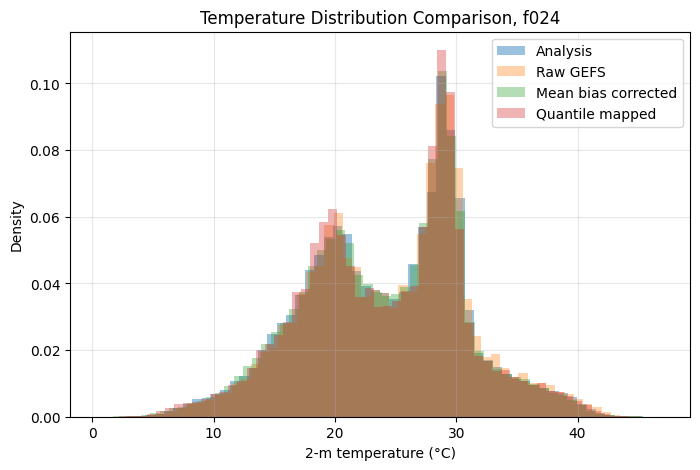

In [31]:
plot_distribution_comparison(test_ds, mean_bias_corrected, qm_corrected, example_fhr)

- The analysis, raw GEFS, mean-bias corrected, and quantile-mapped distributions are very similar at f024.
- This figure supports the interpretation that quantile mapping provides only modest improvement because the raw forecast distribution is already close to the analysis distribution.

## 14. Optional spatial example

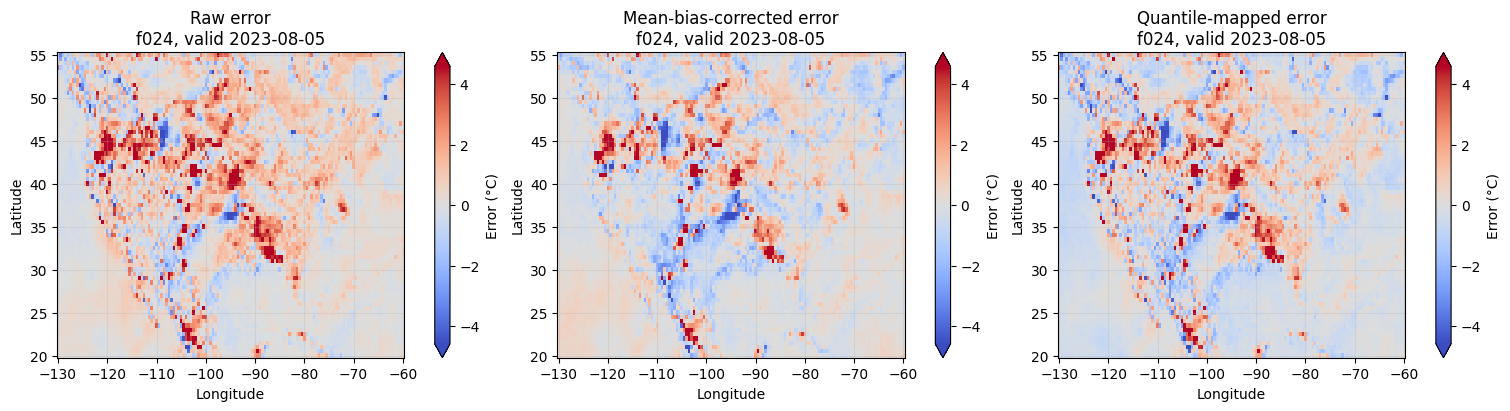

In [29]:
# Plot one test case to visually compare raw, mean-bias, and quantile-mapped forecasts.
example_case = int(test_ds["case"].values[0])
example_fhr = int(test_ds["fhr"].sel(case=example_case).item())
example_valid = pd.to_datetime(test_ds["valid_time"].sel(case=example_case).item())

raw_example = test_ds["forecast_t2m_c"].sel(case=example_case)
analysis_example = test_ds["analysis_t2m_c"].sel(case=example_case)
mean_bias_example = mean_bias_corrected.sel(case=example_case)
qm_example = qm_corrected.sel(case=example_case)

fields = [
    (raw_example - analysis_example, "Raw error"),
    (mean_bias_example - analysis_example, "Mean-bias-corrected error"),
    (qm_example - analysis_example, "Quantile-mapped error"),
]

vmax = max(float(np.nanpercentile(np.abs(field.values), 98)) for field, _ in fields)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, (field, title) in zip(axes, fields):
    field.plot(
        ax=ax,
        x="longitude",
        y="latitude",
        cmap="coolwarm",
        vmin=-vmax,
        vmax=vmax,
        cbar_kwargs={"label": "Error (°C)"},
    )
    ax.set_title(f"{title}\nf{example_fhr:03d}, valid {example_valid:%Y-%m-%d}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, alpha=0.25)

fig.savefig(FIGURE_DIR / "example_error_maps_quantile_mapping.png", dpi=150, bbox_inches="tight")
plt.show()

- Mean-bias correction reduces some warm-error regions more clearly than pooled quantile mapping, supporting the result that mean-bias correction is more effective for RMSE reduction in this case.

## 15. Summary and discussion

- This notebook tested pooled lead-time-dependent quantile mapping for GEFS 2-m temperature bias correction.
- Quantile mapping was compared with raw GEFS and mean-bias correction using RMSE, MAE, bias, and diagnostic figures.
- Quantile mapping improved RMSE compared with raw GEFS in this experiment, but the improvement was smaller than mean-bias correction.
- Distribution plots showed that the raw GEFS and analysis temperature distributions were already similar, so quantile mapping had limited room for large improvement.


- These results suggest that spatial mean-bias correction is more effective than pooled distribution correction for this setup.


- The next project step is to test machine-learning-based bias correction.

###Note on AI Assistance

This notebook was developed with AI. See the repository README for details.